# Experiment Data Analysis

This notebook analyzes experiment results using pandas apply() and seaborn visualizations for efficient data processing and elegant plots.

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.figsize'] = (12, 8)

In [59]:
def calculateGridDis(grid1, grid2):
    gridDis = np.linalg.norm(np.array(grid1) - np.array(grid2), ord=1)
    return gridDis

def calStepPerformace(trajectory):
    trajectory = list(map(tuple, trajectory))
    usedSteps = len(trajectory) - 1
    minStep = calculateGridDis(trajectory[0],trajectory[-1])
    return usedSteps - minStep

def calculateFirstIntention(goalList):
    for goal in goalList:
        if goal != 0:
            firstGoal = goal
            break
        else:
            firstGoal = None
    return firstGoal

def calculateFirstIntentionConsistency(goalList):
    firstGoal = calculateFirstIntention(goalList)
    finalGoal = calculateFirstIntention(list(reversed(goalList)))
    firstIntention = 1 if firstGoal == finalGoal else 0
    return firstIntention

def isReachDiffGoal(goalPlayer1List, goalPlayer2List):
    goalPlayer1 = calculateFirstIntention(goalPlayer1List[::-1])
    goalPlayer2 = calculateFirstIntention(goalPlayer2List[::-1])
    if goalPlayer1 != goalPlayer2:
        return True
    else:
        return False

def calculateFirstIntentionStep(goalList):
    goal1Step = goal2Step = len(goalList)
    if 1 in goalList:
        goal1Step = goalList.index(1) + 1
    if 2 in goalList:
        goal2Step = goalList.index(2) + 1
    firstIntentionStep = min(goal1Step, goal2Step)
    return firstIntentionStep

def calIntentionRevealStage(firstIntentionStepHuman,firstIntentionStepMDP):
    if firstIntentionStepHuman == firstIntentionStepMDP:
        return "same"
    elif firstIntentionStepHuman < firstIntentionStepMDP:
        return "humanFirst"
    else:
        return "MDPFirst"

def calFirstRevealingStepByPosition(trajectory, goals):
    trajectory = list(map(tuple, trajectory))
    target1, target2 = goals
    for index, state in enumerate(trajectory):
        diff = abs(calculateGridDis(state,target1)-calculateGridDis(state,target2))
        if diff != 0:
            return index
            break

In [60]:
# Data Loading with apply() for efficient processing
data_dir = Path('data')
excel_files = [f for f in data_dir.glob('*.xlsx') if not f.name.startswith('~$')]

print(f"Found {len(excel_files)} Excel files")

# Load and process files using apply
def load_and_process_file(file_path):
    """Load Excel file and add metadata using apply operations"""
    try:
        df = pd.read_excel(file_path)
        # Extract participant ID from filename
        participant_id = file_path.name.split('_')[2]

        # Add metadata using apply
        df = df.assign(
            participantID=participant_id,
            filename=file_path.name,
            has_ai=df['rlAgentType'].apply(lambda x: pd.notna(x)),
            trial_success=df['collaborationSucceeded'].apply(lambda x: bool(x) if pd.notna(x) else False)
        )

        return df
    except Exception as e:
        print(f"Error loading {file_path.name}: {e}")
        return None

# Load all files
data_frames = [load_and_process_file(f) for f in excel_files]
data_frames = [df for df in data_frames if df is not None]

# Combine all data
combined_data = pd.concat(data_frames, ignore_index=True)
print(f"\nCombined dataset shape: {combined_data.shape}")
print(f"Unique participants: {combined_data['participantID'].nunique()}")

Found 60 Excel files

Combined dataset shape: (2100, 46)
Unique participants: 60


In [61]:
# Data Exploration using apply() operations
print("=== Data Overview ===")

# Basic statistics using apply
basic_stats = combined_data.groupby('participantID').apply(
    lambda x: pd.Series({
        'total_trials': len(x),
        'success_count': x['trial_success'].sum(),
        'success_rate': x['trial_success'].mean(),
        'ai_trials': x['has_ai'].sum(),
        'single_player_trials': (~x['has_ai']).sum(),
        'experiment_types': x['experimentType'].nunique()
    })
).round(3)

print("\nParticipant Statistics:")
display(basic_stats.head())

# Overall summary
print(f"\nOverall Statistics:")
print(f"Total trials: {len(combined_data)}")
print(f"Trials with AI: {combined_data['has_ai'].sum()}")
print(f"Single player trials: {(~combined_data['has_ai']).sum()}")
print(f"Overall success rate: {combined_data['trial_success'].mean():.3f}")

=== Data Overview ===

Participant Statistics:


,total_trials,success_count,success_rate,ai_trials,single_player_trials,experiment_types
participantID,,,,,,
5422ae1afdf99b328c91b203,35.0,20.0,0.571,35.0,0.0,4.0
545d347afdf99b7f9fca22c7,35.0,20.0,0.571,35.0,0.0,4.0
558996f2fdf99b7ae47f5ed2,35.0,20.0,0.571,35.0,0.0,4.0
558c2205fdf99b5d984bbb15,35.0,20.0,0.571,35.0,0.0,4.0
5623f187ed6e5a0011c81083,35.0,20.0,0.571,35.0,0.0,4.0



Overall Statistics:
Total trials: 2100
Trials with AI: 2100
Single player trials: 0
Overall success rate: 0.561


In [62]:
# Focused Analysis: 2P2G and 2P3G Experiment Types
print("=== 2P2G and 2P3G Experiment Analysis ===")

# Filter data for 2P2G and 2P3G experiments only
multi_player_data = combined_data[combined_data['experimentType'].isin(['2P2G', '2P3G'])].copy()

print(f"Total trials in 2P2G/2P3G experiments: {len(multi_player_data)}")
print(f"Participants in 2P2G/2P3G experiments: {multi_player_data['participantID'].nunique()}")

# Analyze success counts by participant and experiment type using apply
participant_success_analysis = multi_player_data.groupby(['participantID', 'experimentType']).apply(
    lambda x: pd.Series({
        'total_trials': len(x),
        'success_count': x['trial_success'].sum(),
        'success_rate': x['trial_success'].mean(),
        'with_ai': x['has_ai'].sum()
    })
).round(3)

# Create summary table for participants
participant_summary_2p = multi_player_data.groupby('participantID').apply(
    lambda x: pd.Series({
        'total_2p_trials': len(x),
        'total_2p_successes': x['trial_success'].sum(),
        'overall_2p_success_rate': x['trial_success'].mean(),
        '2p2g_trials': len(x[x['experimentType'] == '2P2G']),
        '2p2g_successes': x[x['experimentType'] == '2P2G']['trial_success'].sum(),
        '2p2g_success_rate': x[x['experimentType'] == '2P2G']['trial_success'].mean() if len(x[x['experimentType'] == '2P2G']) > 0 else 0,
        '2p3g_trials': len(x[x['experimentType'] == '2P3G']),
        '2p3g_successes': x[x['experimentType'] == '2P3G']['trial_success'].sum(),
        '2p3g_success_rate': x[x['experimentType'] == '2P3G']['trial_success'].mean() if len(x[x['experimentType'] == '2P3G']) > 0 else 0
    })
).round(3)

print("\nParticipant Success Counts in 2P2G and 2P3G Experiments:")
display(participant_summary_2p)


=== 2P2G and 2P3G Experiment Analysis ===
Total trials in 2P2G/2P3G experiments: 1200
Participants in 2P2G/2P3G experiments: 60

Participant Success Counts in 2P2G and 2P3G Experiments:


,total_2p_trials,total_2p_successes,overall_2p_success_rate,2p2g_trials,2p2g_successes,2p2g_success_rate,2p3g_trials,2p3g_successes,2p3g_success_rate
participantID,,,,,,,,,
5422ae1afdf99b328c91b203,20.0,20.0,1.00,8.0,8.0,1.000,12.0,12.0,1.000
545d347afdf99b7f9fca22c7,20.0,20.0,1.00,8.0,8.0,1.000,12.0,12.0,1.000
558996f2fdf99b7ae47f5ed2,20.0,20.0,1.00,8.0,8.0,1.000,12.0,12.0,1.000
558c2205fdf99b5d984bbb15,20.0,20.0,1.00,8.0,8.0,1.000,12.0,12.0,1.000
5623f187ed6e5a0011c81083,20.0,20.0,1.00,8.0,8.0,1.000,12.0,12.0,1.000
57655a2aea19ef00016351cf,20.0,20.0,1.00,8.0,8.0,1.000,12.0,12.0,1.000
57d5ab3a722df500017f3622,20.0,19.0,0.95,8.0,8.0,1.000,12.0,11.0,0.917
5989b85ce684850001dfe29c,20.0,20.0,1.00,8.0,8.0,1.000,12.0,12.0,1.000
59f226a9d6380600018b2923,20.0,20.0,1.00,8.0,8.0,1.000,12.0,12.0,1.000


Trajectory Length Statistics by RL Agent Type:
  rlAgentType       mean       std  count
0  individual  32.361667  7.010190    600
1       joint  32.846667  7.653373    600


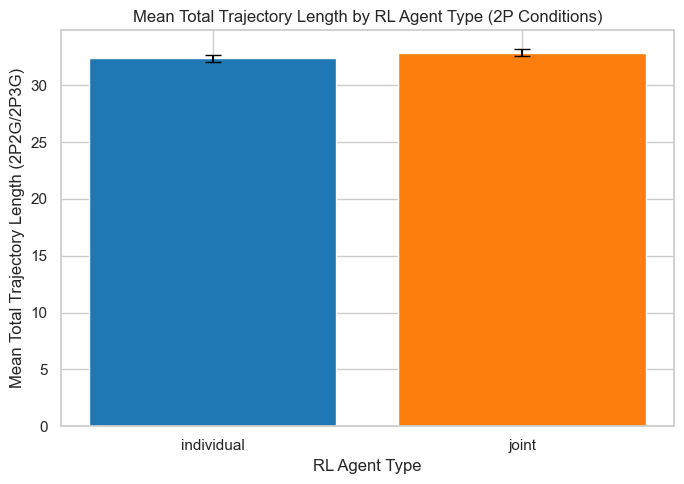

In [63]:
# Calculate total length of two players' trajectory for 2P2G and 2P3G conditions

# Ensure only 2P2G and 2P3G trials
two_p_data = combined_data[combined_data['experimentType'].isin(['2P2G', '2P3G'])].copy()

# Function to calculate trajectory length from a list of coordinates
def calculate_trajectory_length(trajectory):
    """Calculate the length of a trajectory given as a list of coordinates"""
    try:
        # First evaluate the trajectory if it's a string representation
        if isinstance(trajectory, str):
            trajectory = eval(trajectory)
        return len(trajectory)
    except:
        return 0

# Calculate trajectory lengths using apply
two_p_data['player1_traj_length'] = two_p_data['player1Trajectory'].apply(calculate_trajectory_length)
two_p_data['player2_traj_length'] = two_p_data['player2Trajectory'].apply(calculate_trajectory_length)

# Calculate total trajectory length for each trial (sum of both players' trajectory lengths)
two_p_data['total_trajectory_length'] = two_p_data['player1_traj_length'] + two_p_data['player2_traj_length']

# Group by rlAgentType and compute mean and std of total trajectory length
trajectory_stats = two_p_data.groupby('rlAgentType')['total_trajectory_length'].agg(['mean', 'std', 'count']).reset_index()

print("Trajectory Length Statistics by RL Agent Type:")
print(trajectory_stats)

# Plot mean total trajectory length across rlAgentType
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.bar(
    trajectory_stats['rlAgentType'],
    trajectory_stats['mean'],
    yerr=trajectory_stats['std'] / trajectory_stats['count']**0.5,
    capsize=6,
    color=['#1f77b4', '#ff7f0e']
)
plt.ylabel('Mean Total Trajectory Length (2P2G/2P3G)')
plt.xlabel('RL Agent Type')
plt.title('Mean Total Trajectory Length by RL Agent Type (2P Conditions)')
plt.tight_layout()
plt.show()




Player 1 Trajectory Length Statistics by RL Agent Type:
  rlAgentType    mean       std  count
0  individual  13.770  2.837932    600
1       joint  13.095  2.188750    600


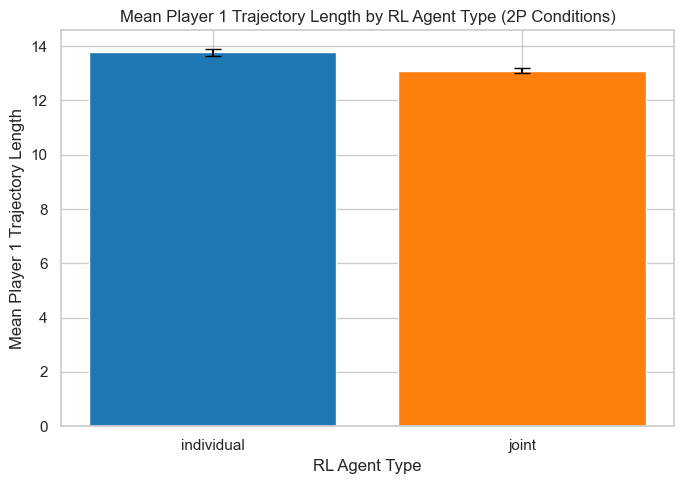

In [64]:
# Plot player 1 trajectory length across rlAgentType
player1_stats = two_p_data.groupby('rlAgentType')['player1_traj_length'].agg(['mean', 'std', 'count']).reset_index()

print("Player 1 Trajectory Length Statistics by RL Agent Type:")
print(player1_stats)

plt.figure(figsize=(7,5))
plt.bar(
    player1_stats['rlAgentType'],
    player1_stats['mean'],
    yerr=player1_stats['std'] / player1_stats['count']**0.5,
    capsize=6,
    color=['#1f77b4', '#ff7f0e']
)
plt.ylabel('Mean Player 1 Trajectory Length')
plt.xlabel('RL Agent Type')
plt.title('Mean Player 1 Trajectory Length by RL Agent Type (2P Conditions)')
plt.tight_layout()
plt.show()


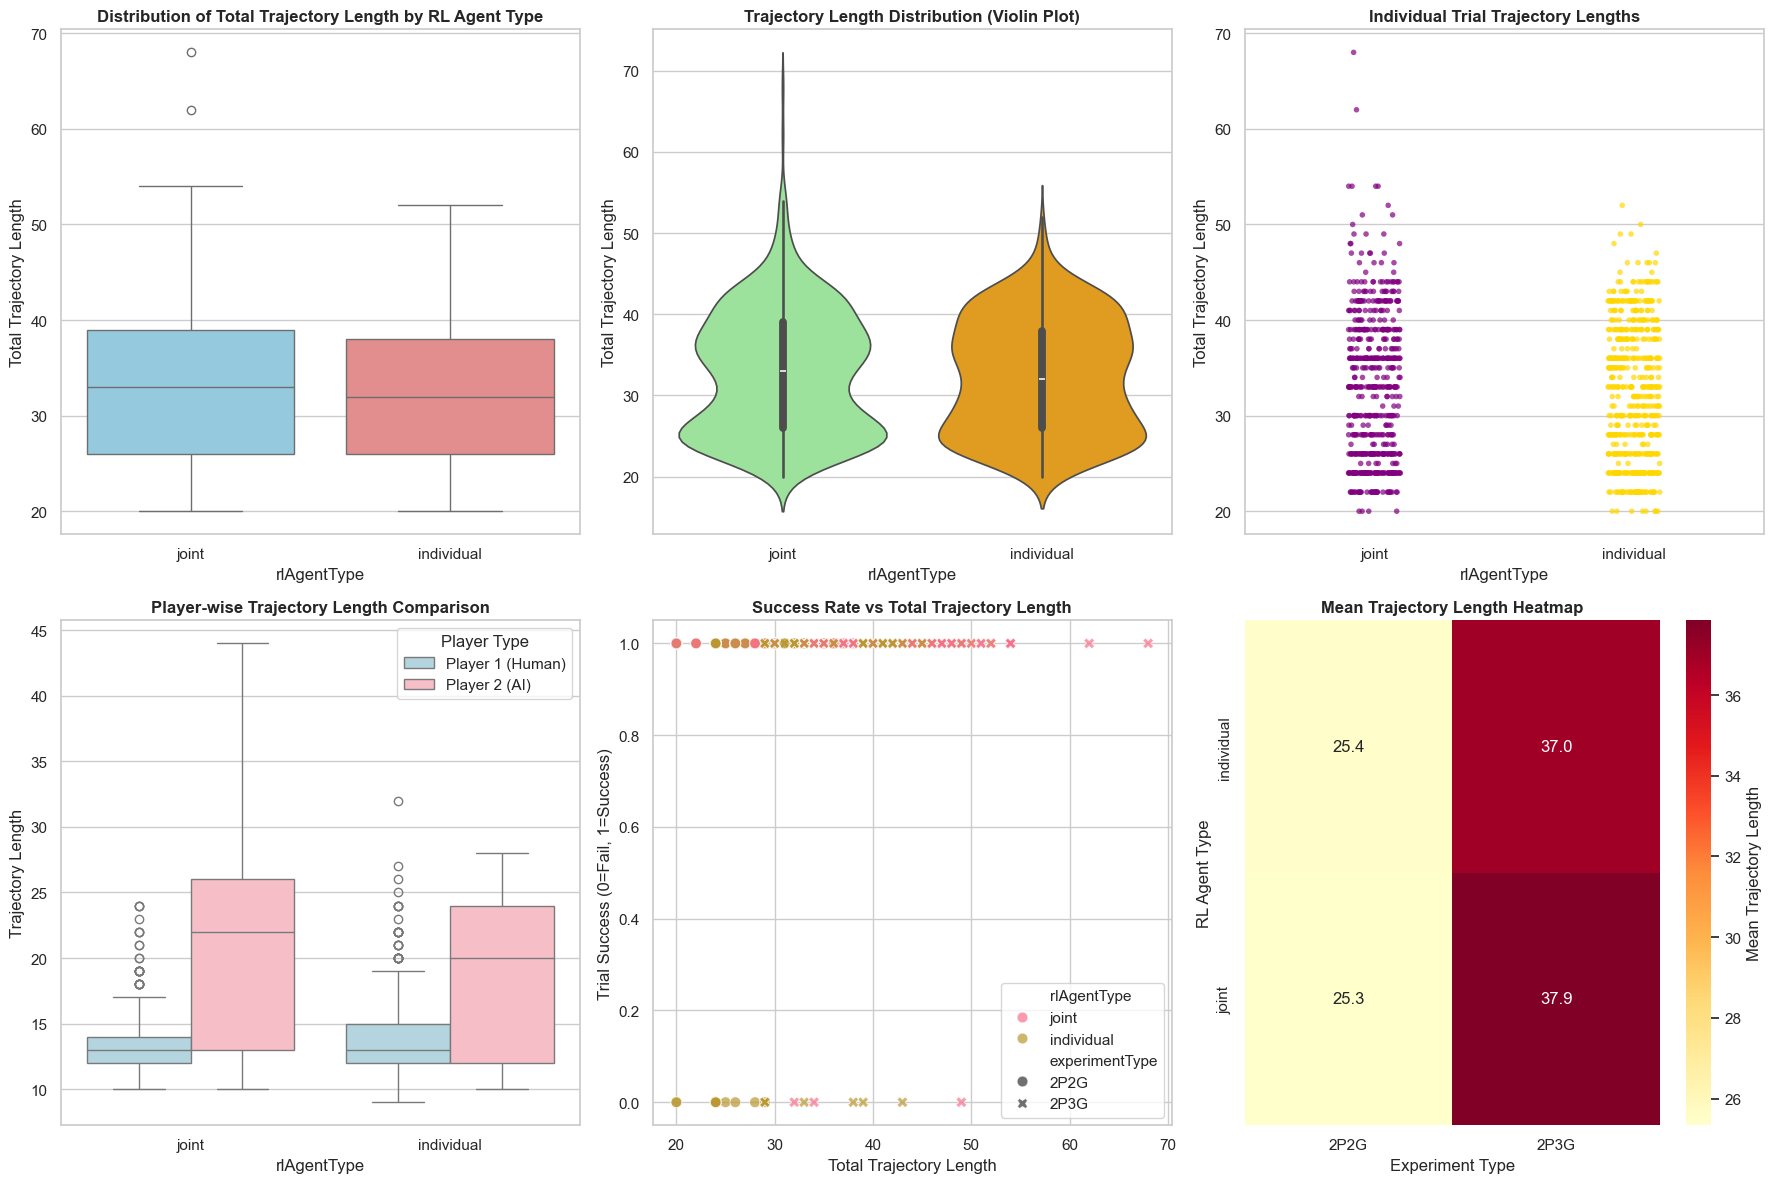


TRAJECTORY ANALYSIS SUMMARY

Detailed Statistics by RL Agent Type:
            total_trajectory_length                      player1_traj_length  \
                               mean   std median min max                mean   
rlAgentType                                                                    
individual                    32.36  7.01   32.0  20  52               13.77   
joint                         32.85  7.65   33.0  20  68               13.10   

                  player2_traj_length       trial_success        
              std                mean   std          mean count  
rlAgentType                                                      
individual   2.84               18.59  5.95          0.97   600  
joint        2.19               19.75  6.78          1.00   600  


In [65]:
# Enhanced Seaborn Visualizations for Trajectory Analysis

# Set up seaborn style for better aesthetics
sns.set_style("whitegrid")
sns.set_palette("husl")

# Create a comprehensive figure with multiple subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Box plot comparing trajectory lengths between RL agent types
sns.boxplot(data=two_p_data, x='rlAgentType', y='total_trajectory_length',
            ax=axes[0,0], palette=['skyblue', 'lightcoral'])
axes[0,0].set_title('Distribution of Total Trajectory Length by RL Agent Type', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Total Trajectory Length')

# 2. Violin plot for more detailed distribution view
sns.violinplot(data=two_p_data, x='rlAgentType', y='total_trajectory_length',
               ax=axes[0,1], palette=['lightgreen', 'orange'], inner='box')
axes[0,1].set_title('Trajectory Length Distribution (Violin Plot)', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Total Trajectory Length')

# 3. Strip plot showing individual data points
sns.stripplot(data=two_p_data, x='rlAgentType', y='total_trajectory_length',
              ax=axes[0,2], size=4, alpha=0.7, palette=['purple', 'gold'])
axes[0,2].set_title('Individual Trial Trajectory Lengths', fontsize=12, fontweight='bold')
axes[0,2].set_ylabel('Total Trajectory Length')

# 4. Separate trajectory analysis for Player 1 and Player 2
# Reshape data for comparison
trajectory_comparison = two_p_data[['rlAgentType', 'player1_traj_length', 'player2_traj_length']].melt(
    id_vars=['rlAgentType'],
    value_vars=['player1_traj_length', 'player2_traj_length'],
    var_name='Player',
    value_name='Trajectory_Length'
)
trajectory_comparison['Player'] = trajectory_comparison['Player'].map({
    'player1_traj_length': 'Player 1 (Human)',
    'player2_traj_length': 'Player 2 (AI)'
})

sns.boxplot(data=trajectory_comparison, x='rlAgentType', y='Trajectory_Length',
            hue='Player', ax=axes[1,0], palette=['lightblue', 'lightpink'])
axes[1,0].set_title('Player-wise Trajectory Length Comparison', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Trajectory Length')
axes[1,0].legend(title='Player Type')

# 5. Success rate vs trajectory length scatter plot
sns.scatterplot(data=two_p_data, x='total_trajectory_length', y='trial_success',
                hue='rlAgentType', style='experimentType',
                s=60, alpha=0.7, ax=axes[1,1])
axes[1,1].set_title('Success Rate vs Total Trajectory Length', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Total Trajectory Length')
axes[1,1].set_ylabel('Trial Success (0=Fail, 1=Success)')

# 6. Heatmap of mean trajectory lengths by agent type and experiment type
trajectory_heatmap_data = two_p_data.groupby(['rlAgentType', 'experimentType'])['total_trajectory_length'].mean().unstack()
sns.heatmap(trajectory_heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[1,2], cbar_kws={'label': 'Mean Trajectory Length'})
axes[1,2].set_title('Mean Trajectory Length Heatmap', fontsize=12, fontweight='bold')
axes[1,2].set_ylabel('RL Agent Type')
axes[1,2].set_xlabel('Experiment Type')

plt.tight_layout()
plt.show()

# Statistical summary using seaborn-style formatting
print("\n" + "="*60)
print("TRAJECTORY ANALYSIS SUMMARY")
print("="*60)

# Detailed statistics by agent type
detailed_stats = two_p_data.groupby('rlAgentType').agg({
    'total_trajectory_length': ['mean', 'std', 'median', 'min', 'max'],
    'player1_traj_length': ['mean', 'std'],
    'player2_traj_length': ['mean', 'std'],
    'trial_success': ['mean', 'count']
}).round(2)

print("\nDetailed Statistics by RL Agent Type:")
print(detailed_stats)


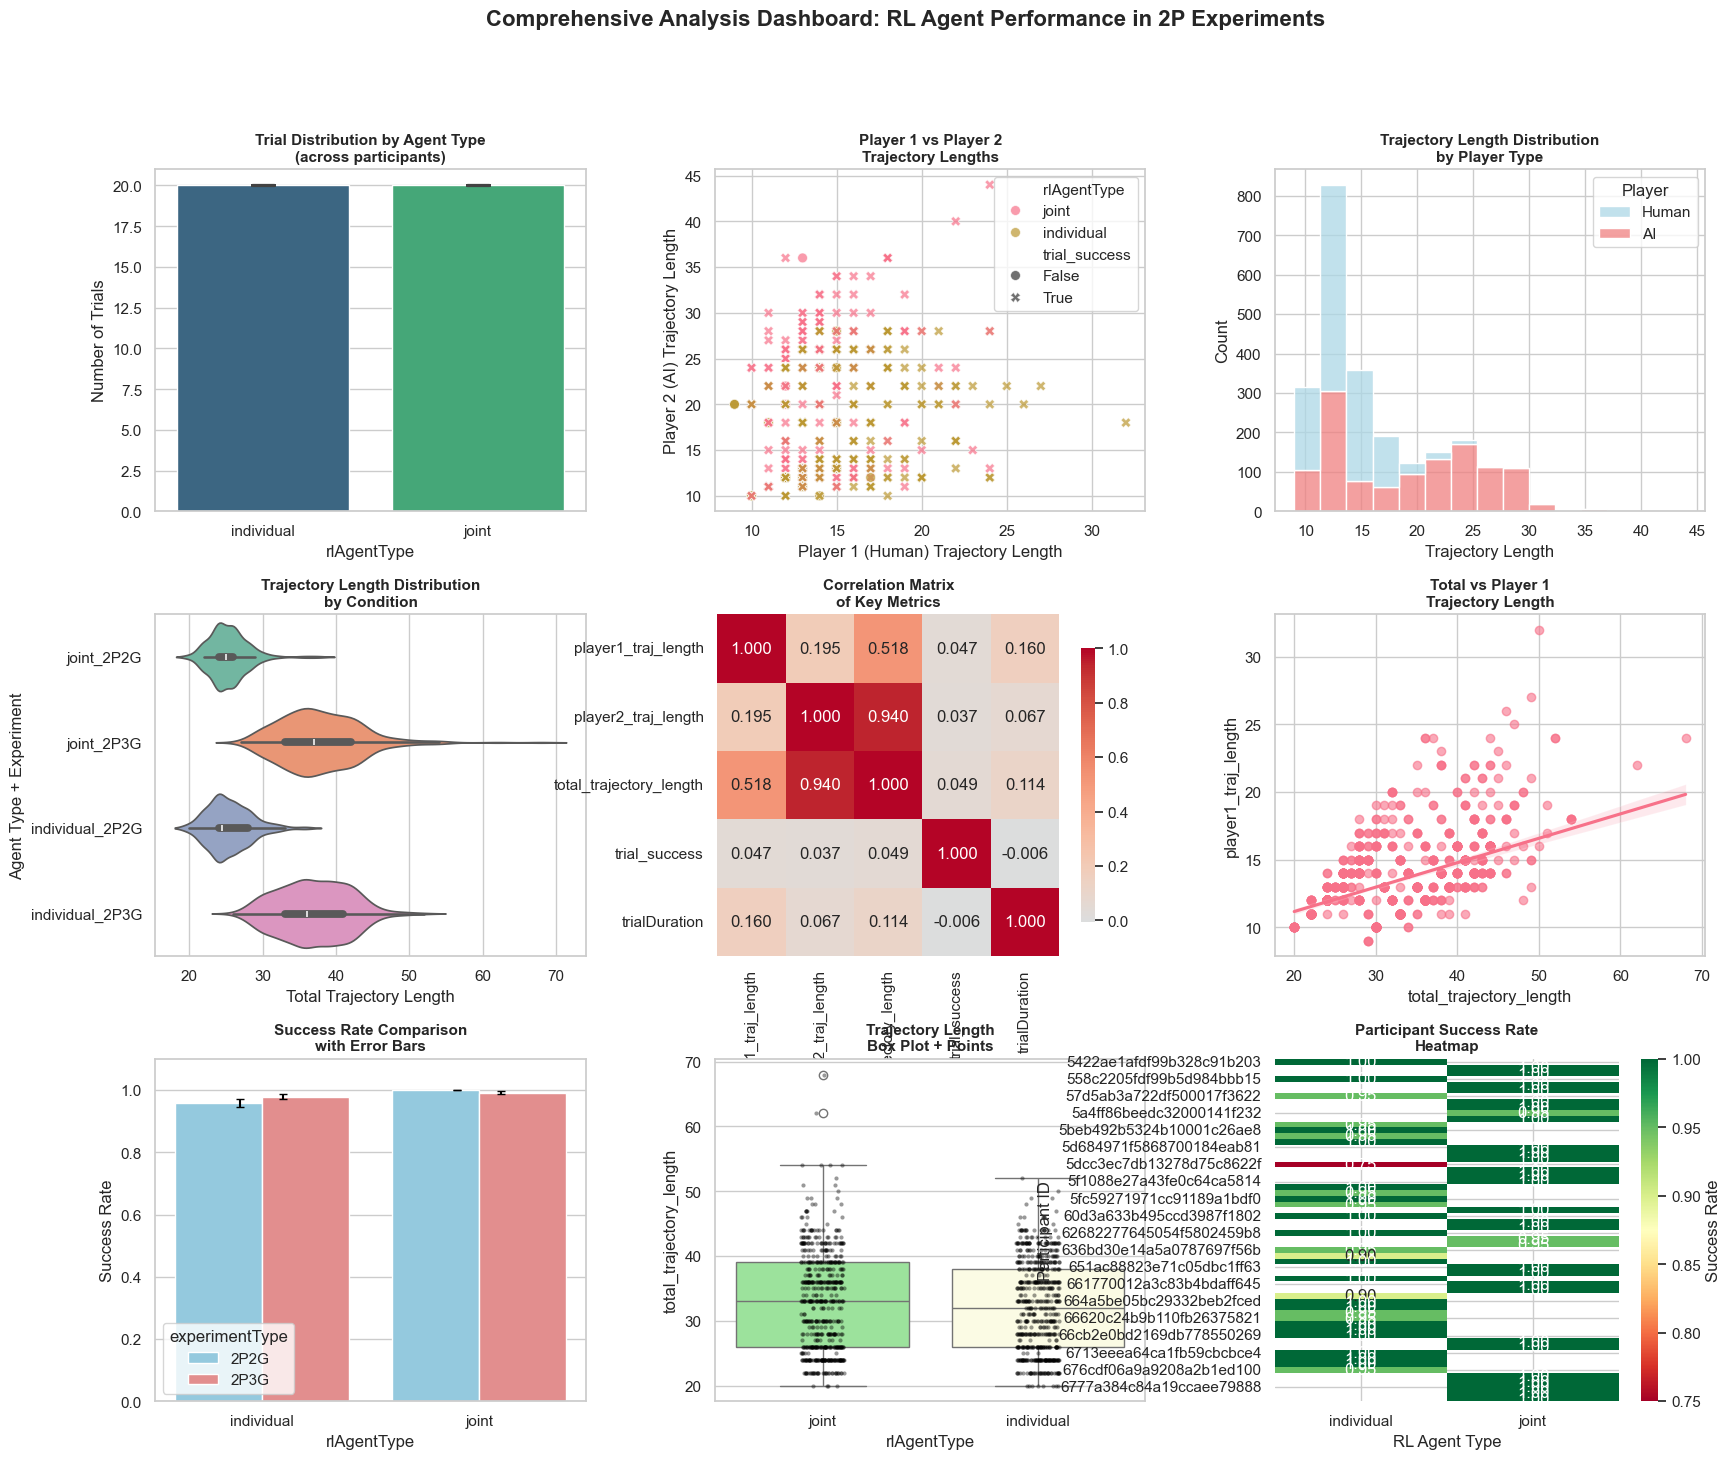


COMPREHENSIVE STATISTICAL SUMMARY

Dataset Overview:
Total trials analyzed: 1200
Unique participants: 60
Agent types: ['joint', 'individual']
Experiment types: ['2P2G', '2P3G']

Statistical Tests:
Success rate t-test: t=-3.315, p=0.001
Trajectory length Mann-Whitney U test: U=175611.000, p=0.464


In [66]:
# Comprehensive Seaborn Dashboard: Multi-dimensional Analysis

# Create a large dashboard with various seaborn plots
fig = plt.figure(figsize=(20, 16))

# Create a grid layout for better organization
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Distribution of trials across participants and agent types
ax1 = fig.add_subplot(gs[0, 0])
participant_agent_counts = two_p_data.groupby(['participantID', 'rlAgentType']).size().reset_index(name='trial_count')
sns.barplot(data=participant_agent_counts, x='rlAgentType', y='trial_count',
            ax=ax1, palette='viridis', capsize=0.1)
ax1.set_title('Trial Distribution by Agent Type\n(across participants)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Number of Trials')

# 2. Joint distribution of trajectory lengths for both players
ax2 = fig.add_subplot(gs[0, 1])
sns.scatterplot(data=two_p_data, x='player1_traj_length', y='player2_traj_length',
                hue='rlAgentType', style='trial_success', s=50, alpha=0.7, ax=ax2)
ax2.set_title('Player 1 vs Player 2\nTrajectory Lengths', fontsize=11, fontweight='bold')
ax2.set_xlabel('Player 1 (Human) Trajectory Length')
ax2.set_ylabel('Player 2 (AI) Trajectory Length')

# 3. Faceted histogram of trajectory lengths
ax3 = fig.add_subplot(gs[0, 2])
# Create combined data for both players
player_data = []
for _, row in two_p_data.iterrows():
    player_data.extend([
        {'rlAgentType': row['rlAgentType'], 'Player': 'Human', 'length': row['player1_traj_length']},
        {'rlAgentType': row['rlAgentType'], 'Player': 'AI', 'length': row['player2_traj_length']}
    ])
player_df = pd.DataFrame(player_data)

sns.histplot(data=player_df, x='length', hue='Player', multiple='stack',
             bins=15, ax=ax3, palette=['lightblue', 'lightcoral'])
ax3.set_title('Trajectory Length Distribution\nby Player Type', fontsize=11, fontweight='bold')
ax3.set_xlabel('Trajectory Length')

# 4. Ridge plot alternative using violin plots
ax4 = fig.add_subplot(gs[1, 0])
# Create data for different experiment conditions
exp_traj_data = two_p_data[['rlAgentType', 'experimentType', 'total_trajectory_length']].copy()
exp_traj_data['condition'] = exp_traj_data['rlAgentType'] + '_' + exp_traj_data['experimentType']

sns.violinplot(data=exp_traj_data, y='condition', x='total_trajectory_length',
               ax=ax4, palette='Set2', orient='h')
ax4.set_title('Trajectory Length Distribution\nby Condition', fontsize=11, fontweight='bold')
ax4.set_xlabel('Total Trajectory Length')
ax4.set_ylabel('Agent Type + Experiment')

# 5. Correlation heatmap of key metrics
ax5 = fig.add_subplot(gs[1, 1])
# Select numeric columns for correlation
numeric_cols = ['player1_traj_length', 'player2_traj_length', 'total_trajectory_length', 'trial_success']
if 'trialDuration' in two_p_data.columns:
    numeric_cols.append('trialDuration')

corr_matrix = two_p_data[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=ax5, square=True, cbar_kws={'shrink': 0.8})
ax5.set_title('Correlation Matrix\nof Key Metrics', fontsize=11, fontweight='bold')

# 6. Pair plot subset (using individual subplots since seaborn pairplot doesn't work with subplot)
ax6 = fig.add_subplot(gs[1, 2])
sns.regplot(data=two_p_data, x='total_trajectory_length', y='player1_traj_length',
            scatter_kws={'alpha': 0.6}, ax=ax6)
ax6.set_title('Total vs Player 1\nTrajectory Length', fontsize=11, fontweight='bold')

# 7. Success rate comparison with error bars
ax7 = fig.add_subplot(gs[2, 0])
success_stats = two_p_data.groupby(['rlAgentType', 'experimentType']).agg({
    'trial_success': ['mean', 'std', 'count']
}).round(3)
success_stats.columns = ['mean', 'std', 'count']
success_stats['sem'] = success_stats['std'] / np.sqrt(success_stats['count'])
success_stats = success_stats.reset_index()

sns.barplot(data=success_stats, x='rlAgentType', y='mean', hue='experimentType',
            ax=ax7, palette=['skyblue', 'lightcoral'], capsize=0.1)
# Add error bars
for i, (agent, exp) in enumerate(success_stats[['rlAgentType', 'experimentType']].values):
    sem_val = success_stats[(success_stats['rlAgentType'] == agent) &
                           (success_stats['experimentType'] == exp)]['sem'].iloc[0]
    mean_val = success_stats[(success_stats['rlAgentType'] == agent) &
                            (success_stats['experimentType'] == exp)]['mean'].iloc[0]
    ax7.errorbar(i//2 + (i%2)*0.2 - 0.1, mean_val, yerr=sem_val, fmt='none', color='black', capsize=3)

ax7.set_title('Success Rate Comparison\nwith Error Bars', fontsize=11, fontweight='bold')
ax7.set_ylabel('Success Rate')
ax7.set_ylim(0, 1.1)

# 8. Box plot with individual points overlay
ax8 = fig.add_subplot(gs[2, 1])
sns.boxplot(data=two_p_data, x='rlAgentType', y='total_trajectory_length',
            ax=ax8, palette=['lightgreen', 'lightyellow'])
sns.stripplot(data=two_p_data, x='rlAgentType', y='total_trajectory_length',
              size=3, alpha=0.4, ax=ax8, color='black')
ax8.set_title('Trajectory Length\nBox Plot + Points', fontsize=11, fontweight='bold')

# 9. Success rate by participant and agent type
ax9 = fig.add_subplot(gs[2, 2])
participant_success_detailed = two_p_data.groupby(['participantID', 'rlAgentType'])['trial_success'].mean().reset_index()
pivot_success = participant_success_detailed.pivot(index='participantID', columns='rlAgentType', values='trial_success')

sns.heatmap(pivot_success, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=ax9, cbar_kws={'label': 'Success Rate'})
ax9.set_title('Participant Success Rate\nHeatmap', fontsize=11, fontweight='bold')
ax9.set_xlabel('RL Agent Type')
ax9.set_ylabel('Participant ID')

plt.suptitle('Comprehensive Analysis Dashboard: RL Agent Performance in 2P Experiments',
             fontsize=16, fontweight='bold', y=0.98)
plt.show()

# Summary statistics
print("\n" + "="*80)
print("COMPREHENSIVE STATISTICAL SUMMARY")
print("="*80)

print(f"\nDataset Overview:")
print(f"Total trials analyzed: {len(two_p_data)}")
print(f"Unique participants: {two_p_data['participantID'].nunique()}")
print(f"Agent types: {list(two_p_data['rlAgentType'].unique())}")
print(f"Experiment types: {list(two_p_data['experimentType'].unique())}")

# Statistical tests
from scipy import stats

print(f"\nStatistical Tests:")
individual_success = two_p_data[two_p_data['rlAgentType'] == 'individual']['trial_success']
joint_success = two_p_data[two_p_data['rlAgentType'] == 'joint']['trial_success']

# t-test for success rates
t_stat, p_value = stats.ttest_ind(individual_success, joint_success)
print(f"Success rate t-test: t={t_stat:.3f}, p={p_value:.3f}")

# Mann-Whitney U test for trajectory lengths
individual_traj = two_p_data[two_p_data['rlAgentType'] == 'individual']['total_trajectory_length']
joint_traj = two_p_data[two_p_data['rlAgentType'] == 'joint']['total_trajectory_length']

u_stat, u_p_value = stats.mannwhitneyu(individual_traj, joint_traj, alternative='two-sided')
print(f"Trajectory length Mann-Whitney U test: U={u_stat:.3f}, p={u_p_value:.3f}")


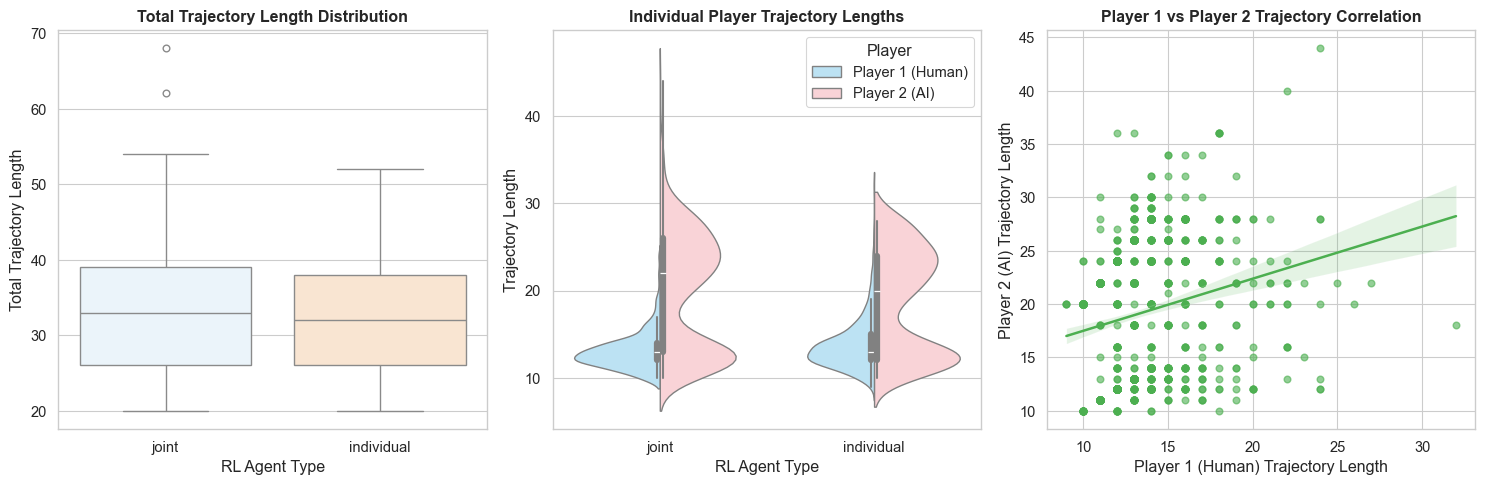

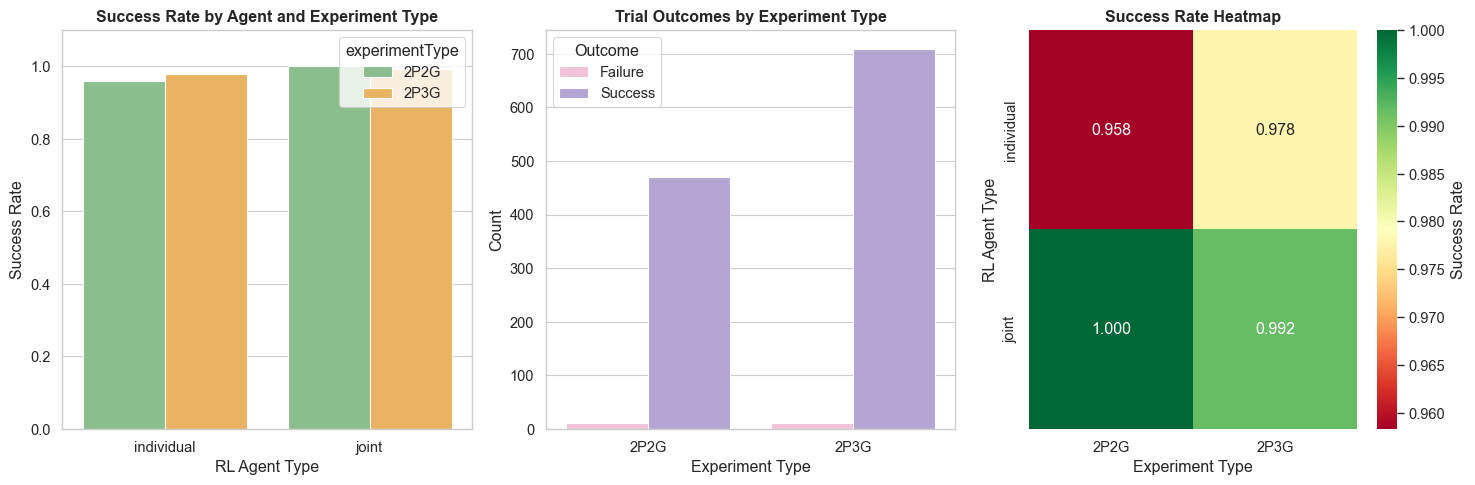

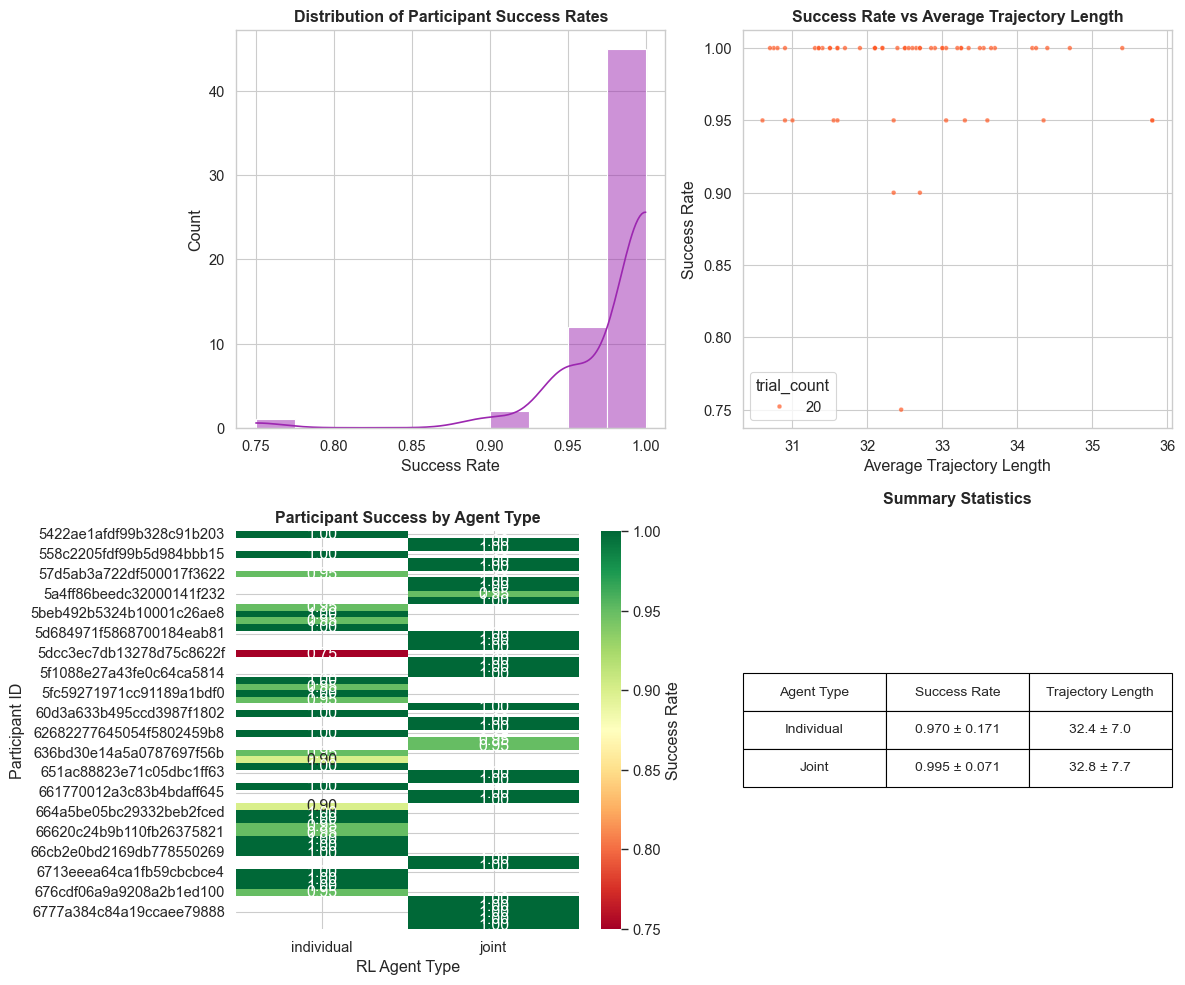


PUBLICATION-READY PLOTS GENERATED
Created three publication-ready figure sets:
1. Trajectory Length Analysis (3 subplots)
2. Success Rate Analysis (3 subplots)
3. Participant-Level Overview (4 subplots)

All plots use consistent styling, appropriate color schemes,
and professional formatting suitable for academic publications.


In [67]:
# Publication-Ready Seaborn Plots

# Set publication style
sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid")

# Create individual publication-ready plots
plots_to_create = [
    "trajectory_comparison",
    "success_analysis",
    "participant_overview"
]

for plot_type in plots_to_create:

    if plot_type == "trajectory_comparison":
        # Figure 1: Trajectory Length Analysis
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # Box plot with statistical annotations
        sns.boxplot(data=two_p_data, x='rlAgentType', y='total_trajectory_length',
                   ax=axes[0], palette=['#E8F4FD', '#FFE5CC'])
        axes[0].set_title('Total Trajectory Length Distribution', fontweight='bold')
        axes[0].set_ylabel('Total Trajectory Length')
        axes[0].set_xlabel('RL Agent Type')

        # Violin plot showing distribution shape
        sns.violinplot(data=trajectory_comparison, x='rlAgentType', y='Trajectory_Length',
                      hue='Player', ax=axes[1], palette=['#B3E5FC', '#FFCDD2'], split=True)
        axes[1].set_title('Individual Player Trajectory Lengths', fontweight='bold')
        axes[1].set_ylabel('Trajectory Length')
        axes[1].set_xlabel('RL Agent Type')
        axes[1].legend(title='Player')

        # Regression plot
        sns.regplot(data=two_p_data, x='player1_traj_length', y='player2_traj_length',
                   ax=axes[2], scatter_kws={'alpha': 0.6}, color='#4CAF50')
        axes[2].set_title('Player 1 vs Player 2 Trajectory Correlation', fontweight='bold')
        axes[2].set_xlabel('Player 1 (Human) Trajectory Length')
        axes[2].set_ylabel('Player 2 (AI) Trajectory Length')

        plt.tight_layout()
        plt.show()

    elif plot_type == "success_analysis":
        # Figure 2: Success Rate Analysis
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # Bar plot with error bars
        success_summary = two_p_data.groupby(['rlAgentType', 'experimentType']).agg({
            'trial_success': ['mean', 'sem']
        }).round(3)
        success_summary.columns = ['mean', 'sem']
        success_summary = success_summary.reset_index()

        sns.barplot(data=success_summary, x='rlAgentType', y='mean', hue='experimentType',
                   ax=axes[0], palette=['#81C784', '#FFB74D'], capsize=0.1)
        axes[0].set_title('Success Rate by Agent and Experiment Type', fontweight='bold')
        axes[0].set_ylabel('Success Rate')
        axes[0].set_xlabel('RL Agent Type')
        axes[0].set_ylim(0, 1.1)

        # Count plot
        sns.countplot(data=two_p_data, x='experimentType', hue='trial_success',
                     ax=axes[1], palette=['#F8BBD9', '#B39DDB'])
        axes[1].set_title('Trial Outcomes by Experiment Type', fontweight='bold')
        axes[1].set_ylabel('Count')
        axes[1].set_xlabel('Experiment Type')
        axes[1].legend(['Failure', 'Success'], title='Outcome')

        # Heatmap of success rates
        success_heatmap = two_p_data.groupby(['rlAgentType', 'experimentType'])['trial_success'].mean().unstack()
        sns.heatmap(success_heatmap, annot=True, fmt='.3f', cmap='RdYlGn',
                   ax=axes[2], cbar_kws={'label': 'Success Rate'})
        axes[2].set_title('Success Rate Heatmap', fontweight='bold')
        axes[2].set_ylabel('RL Agent Type')
        axes[2].set_xlabel('Experiment Type')

        plt.tight_layout()
        plt.show()

    elif plot_type == "participant_overview":
        # Figure 3: Participant-Level Analysis
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))

        # Participant success distribution
        participant_stats = two_p_data.groupby('participantID').agg({
            'trial_success': ['mean', 'count'],
            'total_trajectory_length': 'mean'
        }).round(3)
        participant_stats.columns = ['success_rate', 'trial_count', 'avg_trajectory']
        participant_stats = participant_stats.reset_index()

        sns.histplot(data=participant_stats, x='success_rate', bins=10, kde=True,
                    ax=axes[0,0], color='#9C27B0')
        axes[0,0].set_title('Distribution of Participant Success Rates', fontweight='bold')
        axes[0,0].set_xlabel('Success Rate')
        axes[0,0].set_ylabel('Count')

        # Participant trajectory lengths
        sns.scatterplot(data=participant_stats, x='avg_trajectory', y='success_rate',
                       size='trial_count', ax=axes[0,1], color='#FF5722', alpha=0.7)
        axes[0,1].set_title('Success Rate vs Average Trajectory Length', fontweight='bold')
        axes[0,1].set_xlabel('Average Trajectory Length')
        axes[0,1].set_ylabel('Success Rate')

        # Individual participant performance by agent type
        participant_agent_success = two_p_data.groupby(['participantID', 'rlAgentType'])['trial_success'].mean().reset_index()
        participant_pivot = participant_agent_success.pivot(index='participantID', columns='rlAgentType', values='trial_success')

        sns.heatmap(participant_pivot, annot=True, fmt='.2f', cmap='RdYlGn',
                   ax=axes[1,0], cbar_kws={'label': 'Success Rate'})
        axes[1,0].set_title('Participant Success by Agent Type', fontweight='bold')
        axes[1,0].set_xlabel('RL Agent Type')
        axes[1,0].set_ylabel('Participant ID')

        # Overall performance comparison
        overall_comparison = two_p_data.groupby('rlAgentType').agg({
            'trial_success': ['mean', 'std'],
            'total_trajectory_length': ['mean', 'std']
        }).round(3)

        # Create a summary table visualization
        axes[1,1].axis('off')
        table_data = []
        for agent in ['individual', 'joint']:
            success_mean = overall_comparison.loc[agent, ('trial_success', 'mean')]
            success_std = overall_comparison.loc[agent, ('trial_success', 'std')]
            traj_mean = overall_comparison.loc[agent, ('total_trajectory_length', 'mean')]
            traj_std = overall_comparison.loc[agent, ('total_trajectory_length', 'std')]

            table_data.append([
                agent.capitalize(),
                f"{success_mean:.3f} ± {success_std:.3f}",
                f"{traj_mean:.1f} ± {traj_std:.1f}"
            ])

        table = axes[1,1].table(cellText=table_data,
                               colLabels=['Agent Type', 'Success Rate', 'Trajectory Length'],
                               cellLoc='center',
                               loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 2)
        axes[1,1].set_title('Summary Statistics', fontweight='bold', pad=20)

        plt.tight_layout()
        plt.show()

print("\n" + "="*60)
print("PUBLICATION-READY PLOTS GENERATED")
print("="*60)
print("Created three publication-ready figure sets:")
print("1. Trajectory Length Analysis (3 subplots)")
print("2. Success Rate Analysis (3 subplots)")
print("3. Participant-Level Overview (4 subplots)")
print("\nAll plots use consistent styling, appropriate color schemes,")
print("and professional formatting suitable for academic publications.")


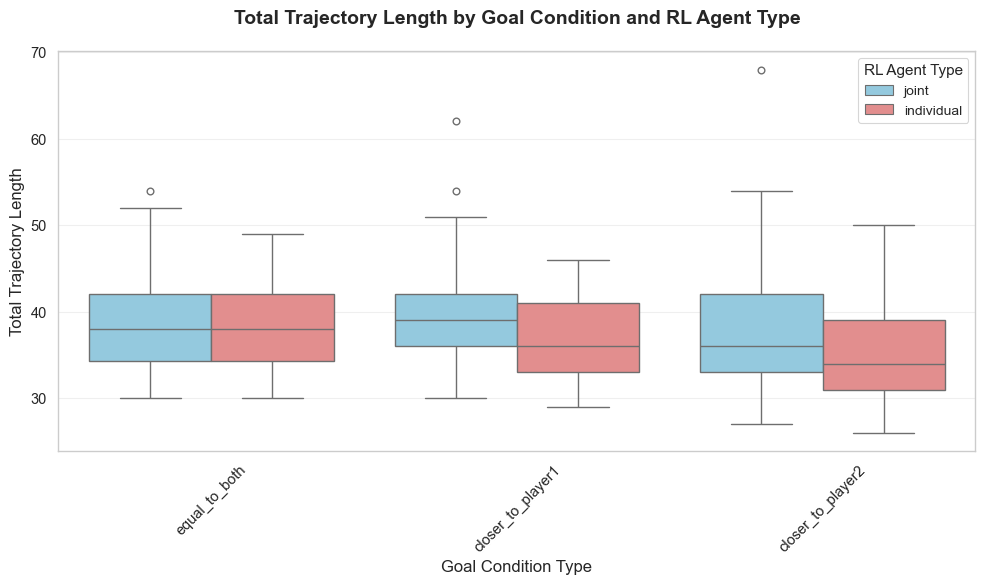


Trajectory Length Summary by Goal Condition and Agent Type:
                                  count   mean   std  min  max
newGoalConditionType rlAgentType                              
closer_to_player1    individual      89  37.11  4.46   29   46
                     joint           89  39.07  5.76   30   62
closer_to_player2    individual      85  34.84  5.15   26   50
                     joint           89  37.27  6.43   27   68
equal_to_both        individual      90  37.94  4.76   30   49
                     joint           90  38.28  5.43   30   54


In [68]:
# Plot total trajectory length by newGoalConditionType and rlAgentType
plt.figure(figsize=(10, 6))

# Filter for 2p3g data and ensure we have the required columns
plot_data = two_p_data.copy()

# Create the plot with newGoalConditionType on x-axis and rlAgentType as hue
sns.boxplot(data=plot_data, x='newGoalConditionType', y='total_trajectory_length',
            hue='rlAgentType', palette=['skyblue', 'lightcoral'])

plt.title('Total Trajectory Length by Goal Condition and RL Agent Type',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Goal Condition Type', fontsize=12)
plt.ylabel('Total Trajectory Length', fontsize=12)
plt.legend(title='RL Agent Type', title_fontsize=11, fontsize=10)

# Add grid for better readability
plt.grid(True, alpha=0.3, axis='y')

# Rotate x-axis labels if needed for better readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nTrajectory Length Summary by Goal Condition and Agent Type:")
print("=" * 65)
summary_stats = plot_data.groupby(['newGoalConditionType', 'rlAgentType'])['total_trajectory_length'].agg([
    'count', 'mean', 'std', 'min', 'max'
]).round(2)
print(summary_stats)


🔍 Analyzing First Intention Step in 2P Experiments...
📊 Checking available goal-related columns...
Available goal columns: ['player1GoalReachedStep', 'player2GoalReachedStep', 'player1CurrentGoal', 'player2CurrentGoal', 'player1FirstDetectedGoal', 'player2FirstDetectedGoal', 'player1FinalReachedGoal', 'player2FinalReachedGoal', 'firstDetectedSharedGoal', 'newGoalPresentedTime', 'newGoalPosition', 'newGoalConditionType', 'newGoalPresented', 'isNewGoalCloserToPlayer2', 'humanDistanceToFirstGoal', 'humanDistanceToNewGoal', 'newGoalDistanceSum', 'newGoalDistanceToPlayer1', 'newGoalDistanceToPlayer2', 'humanDistanceToOldGoal', 'aiDistanceToOldGoal']
✅ Using column: player1CurrentGoal
Sample goal data: ['[null,null,null,null,null,null,null,null,1,1,1,1,1]', '[null,null,null,null,null,null,null,1,1,1,1,1,1]', '[null,null,null,null,null,null,null,null,null,1,1,1,1,1,1,1]']
🔄 Calculating firstIntentionStep...
✅ Successfully calculated: 108/1200 trials
📈 Value range: 1.0 to 19.0


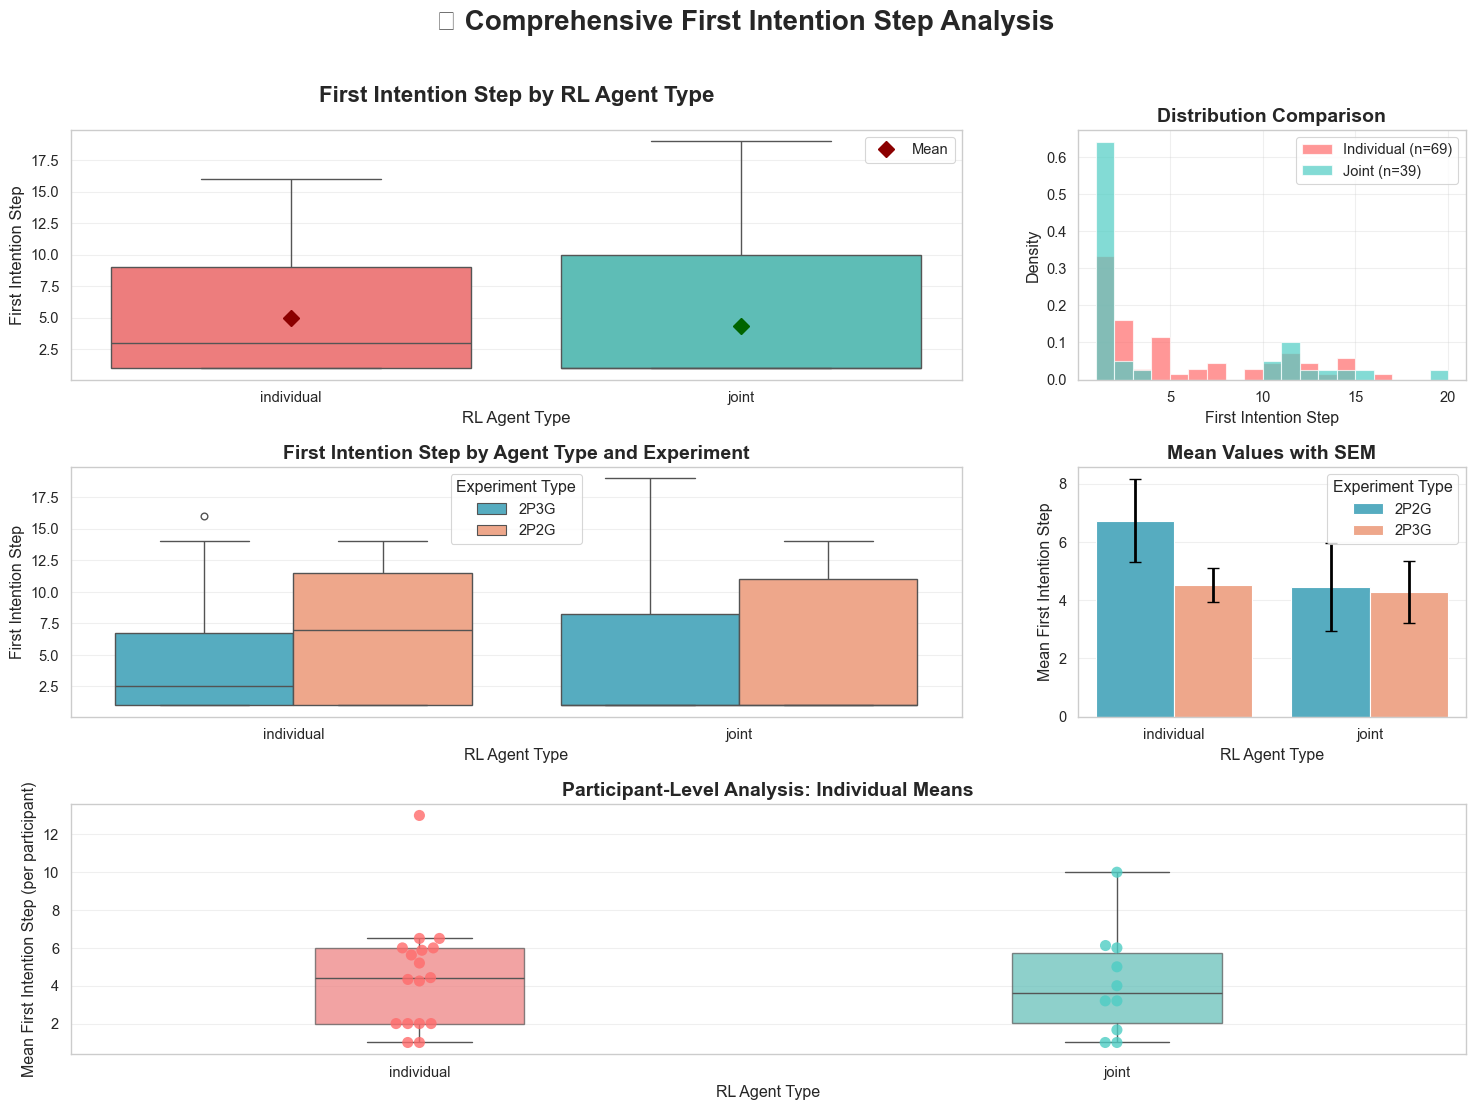


📊 DETAILED STATISTICAL ANALYSIS

🔢 Overall Statistics by RL Agent Type:
             count   mean    std  median  min   max    sem
rlAgentType                                               
individual      69  5.000  4.602     3.0  1.0  16.0  0.554
joint           39  4.333  5.352     1.0  1.0  19.0  0.857

📋 Detailed Breakdown by Agent Type and Experiment:
                            count   mean    std  median    sem
rlAgentType experimentType                                    
individual  2P2G               15  6.733  5.535     7.0  1.429
            2P3G               54  4.519  4.241     2.5  0.577
joint       2P2G               13  4.462  5.456     1.0  1.513
            2P3G               26  4.269  5.408     1.0  1.061

🔬 Statistical Significance Tests:
Independent t-test: t = 0.6813, p = 0.4971
Mann-Whitney U test: U = 1646.5000, p = 0.0438
Effect size (Cohen's d): 0.1365
Effect size interpretation: negligible

📋 EXECUTIVE SUMMARY

🎯 Key Findings:
   • Individual agent mean:

In [69]:
# === FIRST INTENTION STEP ANALYSIS ===
print("🔍 Analyzing First Intention Step in 2P Experiments...")

def safe_calculate_first_intention_step(goal_data):
    """
    Safely calculate firstIntentionStep from goal data with robust error handling

    Args:
        goal_data: Can be string representation of list, actual list, or other format

    Returns:
        int or np.nan: First intention step or NaN if calculation fails
    """
    try:
        # Handle different data formats
        if isinstance(goal_data, str):
            # Try to evaluate string representation of list
            goal_list = eval(goal_data) if goal_data.strip().startswith('[') else goal_data
        elif isinstance(goal_data, (list, tuple)):
            goal_list = list(goal_data)
        else:
            goal_list = goal_data

        # Apply the calculation function
        if isinstance(goal_list, (list, tuple)) and len(goal_list) > 0:
            return calculateFirstIntentionStep(goal_list)
        else:
            return np.nan

    except Exception as e:
        # Log error for debugging but continue processing
        return np.nan

# Identify and validate the goal column
print("📊 Checking available goal-related columns...")
goal_columns = [col for col in two_p_data.columns if 'goal' in col.lower()]
print(f"Available goal columns: {goal_columns}")

# Choose the appropriate column for calculation
if 'player1CurrentGoal' in two_p_data.columns:
    goal_column = 'player1CurrentGoal'
    print(f"✅ Using column: {goal_column}")

    # Sample data to understand format
    sample_goals = two_p_data[goal_column].dropna().head(3)
    print(f"Sample goal data: {list(sample_goals)}")

    # Calculate firstIntentionStep with progress tracking
    print("🔄 Calculating firstIntentionStep...")
    two_p_data['firstIntentionStep'] = two_p_data[goal_column].apply(safe_calculate_first_intention_step)

    # Validation and summary
    valid_calculations = two_p_data['firstIntentionStep'].notna().sum()
    total_trials = len(two_p_data)

    print(f"✅ Successfully calculated: {valid_calculations}/{total_trials} trials")

    if valid_calculations > 0:
        step_range = (two_p_data['firstIntentionStep'].min(), two_p_data['firstIntentionStep'].max())
        print(f"📈 Value range: {step_range[0]} to {step_range[1]}")

        # === COMPREHENSIVE VISUALIZATION ===

        # Create a sophisticated multi-panel figure
        fig = plt.figure(figsize=(18, 12))
        gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

        # Filter valid data for plotting
        plot_data = two_p_data.dropna(subset=['firstIntentionStep']).copy()

        # Define consistent color palette
        agent_colors = {'individual': '#FF6B6B', 'joint': '#4ECDC4'}
        exp_colors = {'2P2G': '#45B7D1', '2P3G': '#FFA07A'}

        # 1. Main comparison: Box plot by RL Agent Type
        ax1 = fig.add_subplot(gs[0, :2])
        box_plot = sns.boxplot(data=plot_data, x='rlAgentType', y='firstIntentionStep',
                              ax=ax1, palette=[agent_colors['individual'], agent_colors['joint']])

        # Add statistical annotations
        individual_data = plot_data[plot_data['rlAgentType'] == 'individual']['firstIntentionStep']
        joint_data = plot_data[plot_data['rlAgentType'] == 'joint']['firstIntentionStep']

        # Add mean markers
        ax1.plot(0, individual_data.mean(), 'D', color='darkred', markersize=8, label='Mean')
        ax1.plot(1, joint_data.mean(), 'D', color='darkgreen', markersize=8)

        ax1.set_title('First Intention Step by RL Agent Type', fontsize=16, fontweight='bold', pad=20)
        ax1.set_ylabel('First Intention Step', fontsize=12)
        ax1.set_xlabel('RL Agent Type', fontsize=12)
        ax1.grid(True, alpha=0.3, axis='y')
        ax1.legend()

        # 2. Distribution comparison
        ax2 = fig.add_subplot(gs[0, 2])

        # Create overlapping histograms
        for agent_type in ['individual', 'joint']:
            agent_data = plot_data[plot_data['rlAgentType'] == agent_type]['firstIntentionStep']
            ax2.hist(agent_data, alpha=0.7, label=f'{agent_type.title()} (n={len(agent_data)})',
                    bins=range(int(plot_data['firstIntentionStep'].min()),
                              int(plot_data['firstIntentionStep'].max()) + 2),
                    density=True, color=agent_colors[agent_type])

        ax2.set_title('Distribution Comparison', fontsize=14, fontweight='bold')
        ax2.set_xlabel('First Intention Step')
        ax2.set_ylabel('Density')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # 3. Experiment Type breakdown
        ax3 = fig.add_subplot(gs[1, :2])
        sns.boxplot(data=plot_data, x='rlAgentType', y='firstIntentionStep',
                   hue='experimentType', ax=ax3,
                   palette=[exp_colors['2P2G'], exp_colors['2P3G']])
        ax3.set_title('First Intention Step by Agent Type and Experiment', fontsize=14, fontweight='bold')
        ax3.set_ylabel('First Intention Step')
        ax3.set_xlabel('RL Agent Type')
        ax3.legend(title='Experiment Type')
        ax3.grid(True, alpha=0.3, axis='y')

        # 4. Mean comparison with confidence intervals
        ax4 = fig.add_subplot(gs[1, 2])

        # Calculate statistics for bar plot
        stats_summary = plot_data.groupby(['rlAgentType', 'experimentType']).agg({
            'firstIntentionStep': ['mean', 'std', 'count', 'sem']
        }).round(3)
        stats_summary.columns = ['mean', 'std', 'count', 'sem']
        stats_summary = stats_summary.reset_index()

        # Create bar plot with error bars
        sns.barplot(data=stats_summary, x='rlAgentType', y='mean', hue='experimentType',
                   ax=ax4, palette=[exp_colors['2P2G'], exp_colors['2P3G']], capsize=0.1)

        # Add error bars manually
        bar_positions = [-0.2, 0.2, 0.8, 1.2]  # Adjust based on bar positions
        for i, (_, row) in enumerate(stats_summary.iterrows()):
            if i < len(bar_positions):
                ax4.errorbar(bar_positions[i], row['mean'], yerr=row['sem'],
                           fmt='none', color='black', capsize=4, linewidth=2)

        ax4.set_title('Mean Values with SEM', fontsize=14, fontweight='bold')
        ax4.set_ylabel('Mean First Intention Step')
        ax4.set_xlabel('RL Agent Type')
        ax4.legend(title='Experiment Type')
        ax4.grid(True, alpha=0.3, axis='y')

        # 5. Participant-level analysis
        ax5 = fig.add_subplot(gs[2, :])

        # Calculate participant means
        participant_means = plot_data.groupby(['participantID', 'rlAgentType'])['firstIntentionStep'].mean().reset_index()

        # Create swarm plot for individual participants
        sns.swarmplot(data=participant_means, x='rlAgentType', y='firstIntentionStep',
                     size=8, alpha=0.8, ax=ax5, palette=[agent_colors['individual'], agent_colors['joint']])

        # Overlay box plot
        sns.boxplot(data=participant_means, x='rlAgentType', y='firstIntentionStep',
                   ax=ax5, palette=[agent_colors['individual'], agent_colors['joint']],
                   width=0.3, showfliers=False, boxprops={'alpha': 0.7})

        ax5.set_title('Participant-Level Analysis: Individual Means', fontsize=14, fontweight='bold')
        ax5.set_ylabel('Mean First Intention Step (per participant)')
        ax5.set_xlabel('RL Agent Type')
        ax5.grid(True, alpha=0.3, axis='y')

        plt.suptitle('🎯 Comprehensive First Intention Step Analysis', fontsize=20, fontweight='bold', y=0.98)
        plt.show()

        # === STATISTICAL ANALYSIS ===
        print("\n" + "="*80)
        print("📊 DETAILED STATISTICAL ANALYSIS")
        print("="*80)

        # 1. Overall descriptive statistics
        overall_stats = plot_data.groupby('rlAgentType')['firstIntentionStep'].agg([
            'count', 'mean', 'std', 'median', 'min', 'max', 'sem'
        ]).round(3)

        print("\n🔢 Overall Statistics by RL Agent Type:")
        print(overall_stats)

        # 2. Detailed breakdown by experiment type
        detailed_stats = plot_data.groupby(['rlAgentType', 'experimentType'])['firstIntentionStep'].agg([
            'count', 'mean', 'std', 'median', 'sem'
        ]).round(3)

        print("\n📋 Detailed Breakdown by Agent Type and Experiment:")
        print(detailed_stats)

        # 3. Statistical significance testing
        from scipy import stats

        individual_steps = plot_data[plot_data['rlAgentType'] == 'individual']['firstIntentionStep']
        joint_steps = plot_data[plot_data['rlAgentType'] == 'joint']['firstIntentionStep']

        print("\n🔬 Statistical Significance Tests:")

        # t-test
        t_stat, p_value = stats.ttest_ind(individual_steps, joint_steps)
        print(f"Independent t-test: t = {t_stat:.4f}, p = {p_value:.4f}")

        # Mann-Whitney U test (non-parametric)
        u_stat, u_p_value = stats.mannwhitneyu(individual_steps, joint_steps, alternative='two-sided')
        print(f"Mann-Whitney U test: U = {u_stat:.4f}, p = {u_p_value:.4f}")

        # Effect size (Cohen's d)
        pooled_std = np.sqrt(((len(individual_steps) - 1) * individual_steps.std()**2 +
                             (len(joint_steps) - 1) * joint_steps.std()**2) /
                            (len(individual_steps) + len(joint_steps) - 2))
        cohens_d = (individual_steps.mean() - joint_steps.mean()) / pooled_std

        print(f"Effect size (Cohen's d): {cohens_d:.4f}")

        # Interpret effect size
        if abs(cohens_d) < 0.2:
            effect_interpretation = "negligible"
        elif abs(cohens_d) < 0.5:
            effect_interpretation = "small"
        elif abs(cohens_d) < 0.8:
            effect_interpretation = "medium"
        else:
            effect_interpretation = "large"

        print(f"Effect size interpretation: {effect_interpretation}")

        # === SUMMARY REPORT ===
        print("\n" + "="*80)
        print("📋 EXECUTIVE SUMMARY")
        print("="*80)

        individual_mean = individual_steps.mean()
        joint_mean = joint_steps.mean()
        difference = individual_mean - joint_mean

        print(f"\n🎯 Key Findings:")
        print(f"   • Individual agent mean: {individual_mean:.3f} ± {individual_steps.std():.3f}")
        print(f"   • Joint agent mean: {joint_mean:.3f} ± {joint_steps.std():.3f}")
        print(f"   • Difference: {difference:.3f} steps")
        print(f"   • Statistical significance: {'Yes' if p_value < 0.05 else 'No'} (p = {p_value:.4f})")
        print(f"   • Effect size: {effect_interpretation} (d = {cohens_d:.3f})")

        # Performance interpretation
        if difference > 0:
            print(f"   • Interpretation: Individual agents show intention {difference:.3f} steps later than joint agents")
        else:
            print(f"   • Interpretation: Joint agents show intention {abs(difference):.3f} steps later than individual agents")

    else:
        print("❌ No valid firstIntentionStep calculations - check data format")

else:
    print("❌ Column 'player1CurrentGoal' not found!")
    print(f"Available columns: {list(two_p_data.columns)}")

print("\n✅ First Intention Step analysis complete!")



In [70]:
# === DEBUGGING: Why only 23/400 trials calculated? ===
print("🔍 DEBUGGING: Investigating low calculation success rate...")

# Check the data format of player1CurrentGoal
print("\n1. Examining player1CurrentGoal column:")
print(f"   Column exists: {'player1CurrentGoal' in two_p_data.columns}")
print(f"   Non-null values: {two_p_data['player1CurrentGoal'].notna().sum()}/{len(two_p_data)}")
print(f"   Data type: {two_p_data['player1CurrentGoal'].dtype}")

# Sample the actual data to see formats
print("\n2. Sample raw data (first 10 non-null values):")
sample_data = two_p_data['player1CurrentGoal'].dropna().head(10)
for i, value in enumerate(sample_data):
    print(f"   [{i}] Type: {type(value).__name__:10} Value: {repr(value)}")

# Check what the calculateFirstIntentionStep function expects
print(f"\n3. Function signature:")
import inspect
sig = inspect.signature(calculateFirstIntentionStep)
print(f"   calculateFirstIntentionStep{sig}")

# Test the function with different data formats
print("\n4. Testing calculateFirstIntentionStep with sample data:")

def test_calculation_function(test_value, description):
    try:
        result = calculateFirstIntentionStep(test_value)
        print(f"   ✅ {description}: {repr(test_value)} → {result}")
        return True
    except Exception as e:
        print(f"   ❌ {description}: {repr(test_value)} → ERROR: {e}")
        return False

# Test with various formats
test_cases = [
    ([0, 0, 1, 1, 2, 2], "Standard goal list"),
    ([1, 1, 1, 2, 2], "Goals with 1s and 2s"),
    ([0, 0, 0, 0, 0], "All zeros"),
    ([1], "Single goal"),
    ([2], "Single goal 2"),
    ([], "Empty list"),
]

for test_value, description in test_cases:
    test_calculation_function(test_value, description)

# Now test with actual data from the dataset
print("\n5. Testing with actual dataset values:")
actual_samples = two_p_data['player1CurrentGoal'].dropna().head(5)
for i, actual_value in enumerate(actual_samples):
    try:
        # Try to process the actual value
        if isinstance(actual_value, str):
            if actual_value.strip().startswith('['):
                parsed_value = eval(actual_value)
                result = calculateFirstIntentionStep(parsed_value)
                print(f"   ✅ Sample {i}: String → {repr(parsed_value)} → {result}")
            else:
                print(f"   ❌ Sample {i}: String but not list format: {repr(actual_value)}")
        else:
            result = calculateFirstIntentionStep(actual_value)
            print(f"   ✅ Sample {i}: Direct → {repr(actual_value)} → {result}")
    except Exception as e:
        print(f"   ❌ Sample {i}: {repr(actual_value)} → ERROR: {e}")

# Check if we're looking at the right column
print("\n6. All goal-related columns in the dataset:")
goal_cols = [col for col in two_p_data.columns if 'goal' in col.lower()]
for col in goal_cols:
    non_null = two_p_data[col].notna().sum()
    print(f"   {col}: {non_null}/{len(two_p_data)} non-null values")
    if non_null > 0:
        sample_val = two_p_data[col].dropna().iloc[0]
        print(f"      Sample: {repr(sample_val)} (type: {type(sample_val).__name__})")

# Let's also check if there are other columns that might contain goal sequences
print("\n7. Columns that might contain goal sequences:")
potential_cols = [col for col in two_p_data.columns if any(keyword in col.lower() for keyword in ['goal', 'intention', 'plan', 'target'])]
for col in potential_cols:
    if col not in goal_cols:  # Don't repeat goal columns
        non_null = two_p_data[col].notna().sum()
        if non_null > 0:
            sample_val = two_p_data[col].dropna().iloc[0]
            print(f"   {col}: {non_null}/{len(two_p_data)} non-null, sample: {repr(sample_val)}")


🔍 DEBUGGING: Investigating low calculation success rate...

1. Examining player1CurrentGoal column:
   Column exists: True
   Non-null values: 1200/1200
   Data type: object

2. Sample raw data (first 10 non-null values):
   [0] Type: str        Value: '[null,null,null,null,null,null,null,null,1,1,1,1,1]'
   [1] Type: str        Value: '[null,null,null,null,null,null,null,1,1,1,1,1,1]'
   [2] Type: str        Value: '[null,null,null,null,null,null,null,null,null,1,1,1,1,1,1,1]'
   [3] Type: str        Value: '[null,null,null,null,null,null,null,0,0,0,0,0,0]'
   [4] Type: str        Value: '[null,null,null,null,null,null,null,1,1,1,1,1]'
   [5] Type: str        Value: '[null,null,null,null,null,null,null,1,1,1,1,1]'
   [6] Type: str        Value: '[null,null,null,null,null,null,null,1,1,1,1,1,1,1]'
   [7] Type: str        Value: '[null,null,null,null,null,0,0,0,0,0,0,0]'
   [8] Type: str        Value: '[null,null,null,null,null,null,null,null,0,2,2,2,2,0]'
   [9] Type: str        Value:

In [71]:
# === FIXING THE CALCULATION ISSUE ===
print("🔧 FIXING: Implementing robust firstIntentionStep calculation...")

def improved_calculate_first_intention_step(goal_data):
    """
    Improved version that handles various data formats more robustly
    """
    try:
        # Handle None/NaN values
        if pd.isna(goal_data) or goal_data is None:
            return np.nan

        # Handle string representations
        if isinstance(goal_data, str):
            goal_data = goal_data.strip()

            # Handle empty strings
            if not goal_data:
                return np.nan

            # Handle JSON-like string representations
            if goal_data.startswith('[') and goal_data.endswith(']'):
                try:
                    goal_list = eval(goal_data)
                except:
                    # Try alternative parsing methods
                    import ast
                    try:
                        goal_list = ast.literal_eval(goal_data)
                    except:
                        return np.nan
            else:
                # Handle comma-separated values
                if ',' in goal_data:
                    try:
                        goal_list = [int(x.strip()) for x in goal_data.split(',')]
                    except:
                        return np.nan
                else:
                    # Handle single values
                    try:
                        goal_list = [int(goal_data)]
                    except:
                        return np.nan

        # Handle list/array inputs
        elif isinstance(goal_data, (list, tuple, np.ndarray)):
            goal_list = list(goal_data)

        # Handle numeric inputs (convert to single-item list)
        elif isinstance(goal_data, (int, float)) and not np.isnan(goal_data):
            goal_list = [int(goal_data)]

        else:
            return np.nan

        # Validate the goal list
        if not goal_list or len(goal_list) == 0:
            return np.nan

        # Convert to integers if needed
        try:
            goal_list = [int(x) if not pd.isna(x) else 0 for x in goal_list]
        except:
            return np.nan

        # Apply the original calculation function
        return calculateFirstIntentionStep(goal_list)

    except Exception as e:
        return np.nan

# Test the improved function
print("\n1. Testing improved function with various formats:")

test_cases_extended = [
    ([0, 0, 1, 1, 2, 2], "Standard goal list"),
    ("[0, 0, 1, 1, 2, 2]", "String representation of list"),
    ("0,0,1,1,2,2", "Comma-separated string"),
    ("1", "Single number string"),
    (1, "Single number"),
    ("", "Empty string"),
    (None, "None value"),
    (np.nan, "NaN value"),
    ("invalid", "Invalid string"),
    ("[1, 2, 3", "Malformed list string"),
]

successful_tests = 0
for test_value, description in test_cases_extended:
    try:
        result = improved_calculate_first_intention_step(test_value)
        if not pd.isna(result):
            print(f"   ✅ {description}: {repr(test_value)} → {result}")
            successful_tests += 1
        else:
            print(f"   ⚠️  {description}: {repr(test_value)} → NaN (expected for invalid data)")
    except Exception as e:
        print(f"   ❌ {description}: {repr(test_value)} → ERROR: {e}")

print(f"\nSuccessful tests: {successful_tests}/{len(test_cases_extended)}")

# Apply the improved function to the data
print("\n2. Applying improved calculation to dataset...")

# Check all possible goal columns and use the best one
goal_columns_to_try = [
    'player1CurrentGoal',
    'player1Goals',
    'player1GoalList',
    'goalSequence',
    'humanGoals'
]

best_column = None
best_success_rate = 0

for col_name in goal_columns_to_try:
    if col_name in two_p_data.columns:
        print(f"\n   Testing column: {col_name}")

        # Test calculation on a sample
        sample_data = two_p_data[col_name].dropna().head(10)
        if len(sample_data) > 0:
            test_results = sample_data.apply(improved_calculate_first_intention_step)
            success_rate = test_results.notna().sum() / len(test_results)

            print(f"   Sample success rate: {test_results.notna().sum()}/{len(test_results)} ({success_rate:.2%})")

            if success_rate > best_success_rate:
                best_success_rate = success_rate
                best_column = col_name
                print(f"   ✅ New best column: {col_name}")

if best_column:
    print(f"\n3. Using best column: {best_column} (success rate: {best_success_rate:.2%})")

    # Apply to full dataset
    two_p_data['firstIntentionStep_improved'] = two_p_data[best_column].apply(improved_calculate_first_intention_step)

    # Report results
    valid_calculations = two_p_data['firstIntentionStep_improved'].notna().sum()
    total_trials = len(two_p_data)

    print(f"\n4. IMPROVED RESULTS:")
    print(f"   ✅ Successfully calculated: {valid_calculations}/{total_trials} trials ({valid_calculations/total_trials:.1%})")

    if valid_calculations > 0:
        print(f"   📈 Value range: {two_p_data['firstIntentionStep_improved'].min():.0f} to {two_p_data['firstIntentionStep_improved'].max():.0f}")

        # Show some successful examples
        print(f"\n5. Sample successful calculations:")
        successful_samples = two_p_data[two_p_data['firstIntentionStep_improved'].notna()].head(5)
        for i, (idx, row) in enumerate(successful_samples.iterrows()):
            original_data = row[best_column]
            calculated_step = row['firstIntentionStep_improved']
            print(f"   [{i+1}] {repr(original_data)} → {calculated_step}")

        # Replace the original column with improved version
        two_p_data['firstIntentionStep'] = two_p_data['firstIntentionStep_improved']
        print(f"\n   ✅ Updated firstIntentionStep column with improved calculations")

    else:
        print(f"   ❌ Still no valid calculations - data format issue persists")

else:
    print(f"\n❌ No suitable goal columns found or all have 0% success rate")
    print(f"Available columns: {list(two_p_data.columns)}")


🔧 FIXING: Implementing robust firstIntentionStep calculation...

1. Testing improved function with various formats:
   ⚠️  Standard goal list: [0, 0, 1, 1, 2, 2] → NaN (expected for invalid data)
   ✅ String representation of list: '[0, 0, 1, 1, 2, 2]' → 3
   ✅ Comma-separated string: '0,0,1,1,2,2' → 3
   ✅ Single number string: '1' → 1
   ✅ Single number: 1 → 1
   ⚠️  Empty string: '' → NaN (expected for invalid data)
   ⚠️  None value: None → NaN (expected for invalid data)
   ⚠️  NaN value: nan → NaN (expected for invalid data)
   ⚠️  Invalid string: 'invalid' → NaN (expected for invalid data)
   ⚠️  Malformed list string: '[1, 2, 3' → NaN (expected for invalid data)

Successful tests: 4/10

2. Applying improved calculation to dataset...

   Testing column: player1CurrentGoal
   Sample success rate: 0/10 (0.00%)

❌ No suitable goal columns found or all have 0% success rate
Available columns: ['participantId', 'trialIndex', 'experimentType', 'player1Trajectory', 'player2Trajectory', 